# IMDb Data Analysis with PySpark

This notebook allows you to interactively run IMDb data analyses using Apache Spark.


## 1. Initialize Spark Session


In [1]:
from pyspark.sql import SparkSession
from utils.reader import read_data

# Create Spark session
spark = SparkSession.builder \
    .appName("IMDBAnalysis-Jupyter") \
    .getOrCreate()

print("Spark session created successfully!")
print(f"Spark version: {spark.version}")


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/02 16:52:11 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/12/02 16:52:11 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


Spark session created successfully!
Spark version: 4.0.1


## 2. Load Data


In [2]:
# Load all dataframes
print("Loading IMDb datasets...")
dataframes = read_data(spark)
print("\nDatasets loaded:")
for name, df in dataframes.items():
    print(f"  - {name}: {df.count():,} rows")


Loading IMDb datasets...

Datasets loaded:


  - name.basics: 14,861,451 rows


  - title.akas: 53,898,347 rows


  - title.basics: 12,048,919 rows


  - title.crew: 12,048,919 rows
  - title.episode: 9,285,221 rows


  - title.principals: 95,709,663 rows
  - title.ratings: 1,634,695 rows


## 3. Run Analyses

Import and run any of the available analyses:


In [3]:
# Import all analysis functions
from analysis import (
    rising_stars,
    fading_stars,
    hook_shows,
    sophomore_slump,
    underrated_genre_combos,
    localization_gaps,
    genre_popularity_trend,
    top_directors_by_high_rating_and_votes,
    director_career_span_analysis
)

print("Analysis functions imported successfully!")


Analysis functions imported successfully!


### Example: Rising Stars Analysis


Analyzing rising stars...


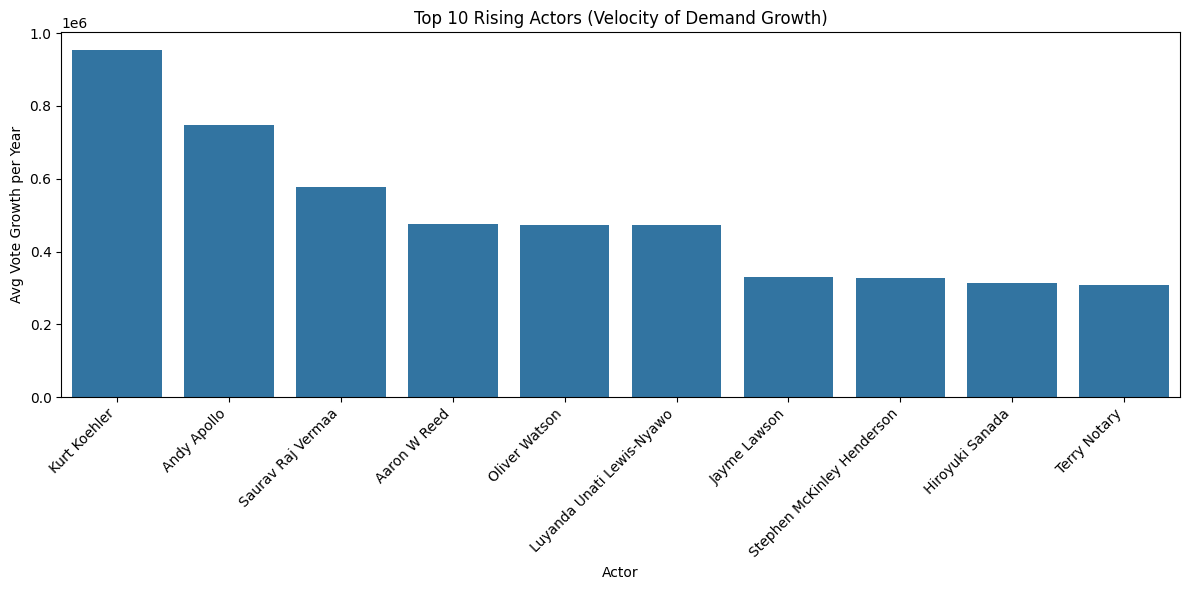

Done! Check visualizations/rising_stars.png


In [4]:
print("Analyzing rising stars...")
rising_stars(dataframes=dataframes, save_path="visualizations")
print("Done! Check visualizations/rising_stars.png")


## 4. Custom Analysis

You can perform custom queries on the data:


In [5]:
from pyspark.sql import functions as F

# Example: Top 10 highest rated movies with at least 10,000 votes
top_movies = dataframes["title.ratings"] \
    .filter(F.col("numVotes") >= 10000) \
    .join(dataframes["title.basics"], "tconst") \
    .filter(F.col("titleType") == "movie") \
    .orderBy(F.col("averageRating").desc()) \
    .select("primaryTitle", "startYear", "averageRating", "numVotes") \
    .limit(10)

print("\nTop 10 Highest Rated Movies (min 10K votes):")
top_movies.show(truncate=False)



Top 10 Highest Rated Movies (min 10K votes):


+---------------------------------------------+---------+-------------+--------+
|primaryTitle                                 |startYear|averageRating|numVotes|
+---------------------------------------------+---------+-------------+--------+
|The Shawshank Redemption                     |1994     |9.3          |3117437 |
|Attack on Titan the Movie: The Last Attack   |2024     |9.2          |21377   |
|The Chaos Class                              |1975     |9.2          |45287   |
|The Godfather                                |1972     |9.2          |2173789 |
|Ramayana: The Legend of Prince Rama          |1993     |9.1          |17393   |
|The Dark Knight                              |2008     |9.1          |3093456 |
|The Godfather Part II                        |1974     |9.0          |1460409 |
|The Lord of the Rings: The Return of the King|2003     |9.0          |2117514 |
|Schindler's List                             |1993     |9.0          |1553877 |
|12 Angry Men               